# **DATA MODELLING**

**Mount your google drive.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## SUPERVISED LEARNING - Regression

###1. Data - Load and Final preperation

**1.1 Read in the processed housing data set from your drive folder using pandas.**

In [2]:
import pandas as pd
import numpy as np

file = "/content/drive/MyDrive/Werk/DIRISA/2026/Training/Modelling/Supervised ML/data_processed.csv"
data = pd.read_csv(file)

**1.2 View the dataset using 'display' or 'head'**

In [3]:
display(data)

,Unnamed: 0,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,...,0.165217,0.000000,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,...,0.765217,0.000000,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,...,0.765217,0.000000,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,...,0.217391,0.000000,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,...,0.886957,0.000000,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,21608,0.114754,0.090909,0.40625,0.208302,0.011129,0.0,1.0,1.0,0.75,...,0.539130,0.000000,0.994949,0.373492,0.160299,0.132679,0.080779,0.0,0.454545,0.633333
21609,21609,0.113443,0.121212,0.31250,0.216604,0.023891,0.0,0.0,0.0,0.50,...,0.695652,0.000000,0.020202,0.781567,0.300664,0.602478,0.041115,0.0,0.545455,0.933333
21610,21610,0.085902,0.121212,0.28125,0.143396,0.005142,0.4,0.0,0.0,0.75,...,0.669565,0.000000,0.161616,0.861670,0.274917,0.308209,0.011028,1.0,0.181818,0.333333
21611,21611,0.235410,0.151515,0.50000,0.318491,0.008877,0.4,0.0,0.0,0.50,...,0.600000,0.993548,0.196970,0.603185,0.241694,0.535364,0.014760,0.0,0.363636,0.166667


There seems to be a extra column due to exporting the dataframe to csv, so lets remove it.

**1.3 Drop the 0 column**

In [4]:
data = data.drop(['Unnamed: 0'],axis=1)
data.head(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day
0,0.098361,0.121212,0.18750,0.120755,0.003888,0.2,0.0,0.0,0.50,0.583333,...,0.165217,0.0,0.580808,0.697603,0.107973,0.223886,0.006432,0.0,0.454545,0.500000
1,0.087213,0.151515,0.43750,0.183396,0.006623,0.4,0.0,0.0,0.50,0.666667,...,0.765217,0.0,0.257576,0.789287,0.332226,0.433832,0.012244,0.0,0.545455,0.700000
2,0.027410,0.090909,0.21875,0.093585,0.005500,0.0,0.0,0.0,0.50,0.500000,...,0.765217,0.0,0.207071,0.327328,0.367940,0.220444,0.010372,1.0,0.181818,0.766667
3,0.049836,0.060606,0.12500,0.086038,0.002714,0.2,0.0,0.0,0.25,0.500000,...,0.217391,0.0,0.575758,0.831269,0.182724,0.180864,0.003560,1.0,0.000000,0.866667
4,0.029115,0.090909,0.31250,0.105660,0.002707,0.4,0.0,0.0,0.50,0.500000,...,0.886957,0.0,0.186869,0.322020,0.418605,0.246257,0.004689,0.0,0.818182,0.433333


Now we have a dataset that is in the correct format and has already been explored a bit during a previous prac.


---



In the excersie after the presentaion we talked about a data set about property sales. We concluded that to create a model to determine the sale price for the given input we would use regression.

**1.4 TEST/TRAIN split**

Since we want to predict the price, lets set our target or 'y' as the price and then remove it from the dataset (X).

y = f(X)

In [5]:
y = data['price']
X = data.drop(['price'],axis=1)

Next we have to **split our dataset** (X) and target (y) into the training and testing data set using the sklearn.model_selection ["train_test_split"](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

###2. Linear Regression

If we think back on the visualistion that we did on this dataset in day 2, we saw some linear relationships between variables.

So lets see how well a linear regression model will do.

**Import the machine learning package LinearRegression from the library 'sklearn'**

In [7]:
from sklearn.linear_model import LinearRegression

**Set your model**

In [8]:
model = LinearRegression()

**Fit the model** to the training data.

In [9]:
model.fit(X_train, y_train)

LinearRegression()

Finaly use the fitted model to **predict the test price** and calculate the accuracy by using "score".

In [11]:
model.score(X_test,y_test)

0.6845047741258912

Grab a sample (row) from the test set so that you can do a prediction.

In [13]:
X_demo = X_test.iloc[5].values.reshape(1,-1)
y_demo = y_test.iloc[5]

Predict the house price for X_demo

In [14]:
y_pred = model.predict(X_demo)
print("Predicted price: " + str(y_pred))
print("Actual price: " + str(y_demo))

Predicted price: [0.04941573]
Actual price: 0.0557377049180327


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Lets see if we can try another algorithms what will let us do some parameter tuning, such as support vector regression.

###3. Non-Linear Regression

Since we want to do some parameter tuning, we do not want to tune the parameters using the testing set. Do you know why?

**Set up a [XGBoot regressor](https://machinelearningmastery.com/xgboost-for-regression/)** with parameters: n_estimators=10, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8.

In [15]:
import xgboost as xgb

In [16]:
mod = xgb.XGBRegressor(n_estimators=10, max_depth=5, eta=0.01, subsample=0.7, colsample_bytree=0.8)

Fit the model with the training data.

In [17]:
mod.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eta=0.01, eval_metric=None,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None, ...)

Calculate the acuracy of the model using the training data.

In [18]:
mod.score(X_train, y_train)

0.1307586023392675

### 4. Hyperparameter Tuning
The next step would be to tune the parameters to get a better result. BUT this can't just be done by changing the values and looking at the test scores, since that may leed to overfitting.

Hence **[cross validation](https://scikit-learn.org/stable/modules/cross_validation.html) should be employed**, using the "cross_validate" sklearn.model_selection function.

Once the cross validation is incorporated, more information on the parameters that can be tuned can be found [here](https://www.geeksforgeeks.org/machine-learning/xgboost-for-regression/).

Change the parameters and see how the score changes. **TIP**: don't 'fine tune' the parameters, rather change the order of magnitude e.g. eta=0.01, 0.1, 1, etc.

In [26]:
from sklearn.model_selection import cross_validate

mod = xgb.XGBRegressor(n_estimators=1000, max_depth=7, eta=0.01, subsample=0.7, colsample_bytree=0.8)
cv_resutls = cross_validate(mod, X, y, cv=3)
print(np.mean(cv_resutls['test_score']))

0.8927045173074437


In [28]:
from sklearn.model_selection import cross_val_score
mod1 = xgb.XGBRegressor(n_estimators=1000, max_depth=7, eta=0.01, subsample=0.7, colsample_bytree=0.8)
score = cross_val_score(mod1, X_train, y_train, cv=3)
print(np.mean(score))

0.890345537932852


Once you are satified with the validation test score, fit the model to the training data and view the score of the test set.

In [30]:
mod1.fit(X_train, y_train)
mod1.score(X_test,y_test)

0.8998034091837468

### 5. Feature Importance
Which features were the most influencial in the prediction? Hint: [Feature importance](https://machinelearningmastery.com/10-python-one-liners-for-calculating-model-feature-importance/).

In [32]:
importances = mod1.feature_importances_
print(importances)

[0.00344119 0.01333892 0.16161144 0.00767642 0.00607618 0.13113013
 0.04617179 0.00824692 0.36966377 0.02385447 0.0093224  0.02133729
 0.00869527 0.0195517  0.06823041 0.03826407 0.03482401 0.01151523
 0.00820942 0.00459395 0.00424513]


Let's plot the importance using matplotlib barh.

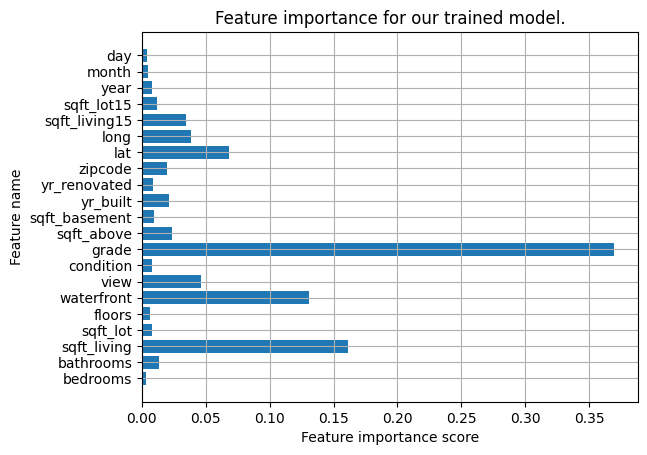

In [35]:
import matplotlib.pyplot as plt
plt.barh(X.columns, importances)
plt.xlabel('Feature importance score')
plt.ylabel('Feature name')
plt.title('Feature importance for our trained model.')
plt.grid()

## SUPERVISED LEARNING - Classification

Lets look at a very simple example for classification.

**Download the (famous) iris dataset** using seaborn

This dataset is already cleaned, so we don't have to check for missing values or outliers. But we will have to
1. Load and look at data so that you can better understand it,
2. Process the data
   - Normalise (just to be safe - it's good practice),
   - Lable encoding,
   - Encode the strings,
   - randomise and split
3. Select and Build the Model.
4. Evaluate the Model.

###1. Look at the data.

Import seaborn and load 'iris' data

In [39]:
import seaborn as sns
iris = sns.load_dataset("iris")


Inspect the data. You can use print and describe().

In [40]:
print(iris)
iris.describe()

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Visualise the data using a seaborn [swarm plot](https://seaborn.pydata.org/generated/seaborn.swarmplot.html).


Set x equal to 'species' and select any one of the other parameters (one of the feature vectors) as y in the plot.

<Axes: xlabel='species', ylabel='sepal_width'>

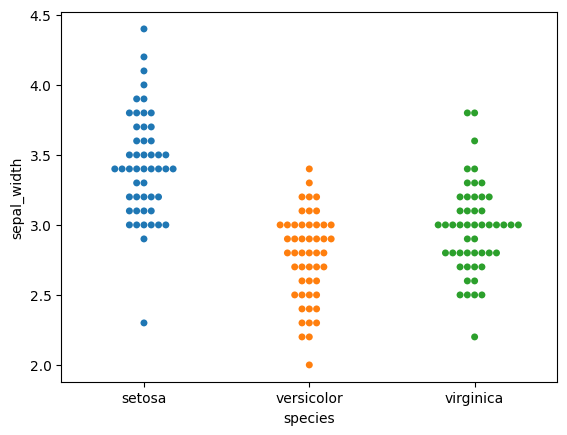

In [44]:
sns.swarmplot(data=iris, x='species', y='sepal_width', hue='species')

###2. Process the data

Let us now roughly follow the procedure from the previous excersise starting with **identifying and setting X and y**.

In [47]:
y = iris["species"]
X = iris.iloc[:,0:4]
y.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


Normalise X using MinMaxScaler.

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X)
X_norm = scaler.transform(X)

This dataset contains strings (in the species column) and so have to be set to integers.
Instead of doing this manualy, a [Label Encoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) can be used.

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
y_transf = le.transform(y)
print(y_transf)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Divide the data into the **train and test** set using test_size=0.3.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_transf, test_size = 0.2, random_state = 42)

###3. Select and Build the Model

Select and set up a classifier (Random Forest).

In [65]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

 Train the dataset using cross_validation and tune the hyperparameters (number of estimators).

In [66]:
from sklearn.model_selection import cross_validate
cros_val_model = cross_validate(clf, X_train, y_train, cv =5)
result = np.mean(cros_val_model['test_score'])
print(result)

0.95


Fit the model with the optimal parameters and predict the test set (X_test).

In [69]:
trained_mod = clf.fit(X_train,y_train)
y_pred = trained_mod.predict(X_test)

###4. Evaluate the Model

Calculate the [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [73]:
from sklearn.metrics import f1_score
score = f1_score(y_test, y_pred, average='weighted')
print(score)

1.0


Lets plot the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) to get a visual on the model performance.

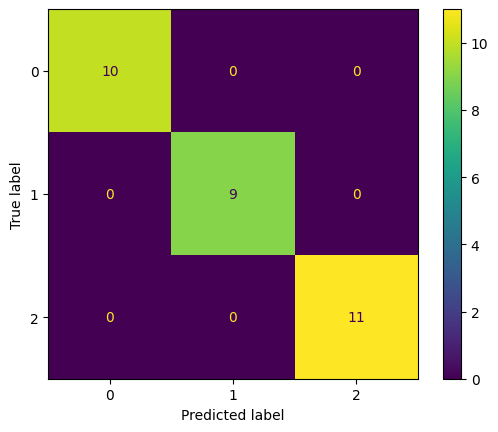

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(trained_mod, X_test, y_test)